# BASTION: New York Electricity Demand Example

This notebook applies BASTION to **daily average electricity demand for New York State (2015-2024)** and showcases the stochastic volatility extension.  It corresponds to Section 6.2 of:

> Cho, J. B. & Matteson, D. S. (2026). *BASTION: A Bayesian Framework for Trend and Seasonality Decomposition.* arXiv:2601.18052.

## Why this dataset?

NY electricity demand (daily, ~3 300 observations) exhibits:
- A mild **long-run trend**.
- A **weekly seasonality** (lower demand on weekends).
- A **yearly seasonality** with summer air-conditioning and winter heating peaks.
- **Heteroskedastic noise** — volatility is higher in summer and winter than in spring and fall.  As the paper states (Section 6.2):

> *'Higher volatility is observed during the winter and summer months, while lower volatility occurs during the spring and fall.'*

The data come from the New York Independent System Operator (NYISO) via the U.S. Energy Information Administration (EIA, 2024).

## What this notebook covers

1. Load and explore the dataset.
2. Fit BASTION with weekly + yearly seasonalities and stochastic volatility (`obsSV='SV'`).
3. Full decomposition — trend, weekly season, yearly season.
4. Time-varying volatility — a feature unique to BASTION.
5. Simulation-average metrics from the paper + in-sample fit statistics.

In [1]:
import os, sys, warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_DIR  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
OUTPUT_DIR   = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
from pybastion import fit_BASTION
from pybastion.datasets import load_NYelectricity

# ── QUICK_MODE ──────────────────────────────────────────────────────
# True  → short MCMC chain, runs in ~15-30 min (suitable for a quick demo).
# False → full MCMC chain, runs in ~3-6 hours.
QUICK_MODE = True

if QUICK_MODE:
    nsave, nburn, nskip, nchains = 100, 200, 1, 1
else:
    nsave, nburn, nskip, nchains = 5000, 5000, 4, 1

nstot = nburn + (nskip + 1) * nsave
print(f'pybastion loaded from: {PROJECT_DIR}')
print(f'QUICK_MODE={QUICK_MODE}: {nstot} total MCMC steps per chain')
print(f'  nsave={nsave}, nburn={nburn}, nskip={nskip}, nchains={nchains}')

pybastion loaded from: /media/daniel/Extreme SSD/Projects/pyBASTION
QUICK_MODE=True: 400 total MCMC steps per chain
  nsave=100, nburn=200, nskip=1, nchains=1


## 1. Load and Explore the Data

Daily average electricity demand (MWh) for New York State from 2015-07-01 to 2024-06-30.  The dataset is bundled with `pybastion` as `load_NYelectricity()`.

Observations : 3288 daily records
Date range   : 2015-07-01 to 2024-06-30
Demand range : 12840 to 27121 MWh


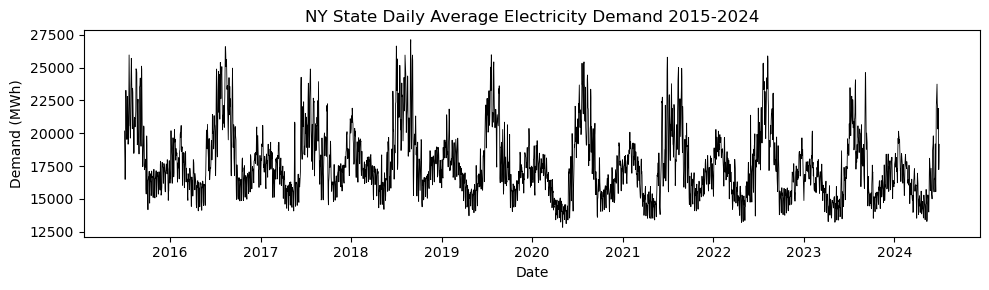

In [2]:
_raw  = load_NYelectricity()
# Raw columns are 'Data.Date' (datetime) and 'Demand..MW.' (float)
elec  = _raw.rename(columns={'Data.Date': 'date', 'Demand..MW.': 'demand'}).copy()
elec['date'] = pd.to_datetime(elec['date'])
print(f'Observations : {len(elec)} daily records')
print(f'Date range   : {elec["date"].min().date()} to {elec["date"].max().date()}')
print(f'Demand range : {elec["demand"].min():.0f} to {elec["demand"].max():.0f} MWh')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(elec['date'], elec['demand'], linewidth=0.6, color='black')
ax.set_xlabel('Date'); ax.set_ylabel('Demand (MWh)')
ax.set_title('NY State Daily Average Electricity Demand 2015-2024')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

## 2. Fit BASTION with Stochastic Volatility

Setting `obsSV='SV'` activates the Kim-Shephard-Chib (1998) stochastic volatility model for the remainder, allowing the noise variance to evolve smoothly over time.

| Parameter | Quick mode | Full mode | Meaning |
|-----------|------------|-----------|--------|
| `Ks` | `[7, 365]` | `[7, 365]` | Weekly + yearly seasonalities |
| `Outlier` | `True` | `True` | Horseshoe+ outlier component |
| `obsSV` | `'SV'` | `'SV'` | Stochastic volatility remainder |
| `sparse` | `True` | `True` | Sparse precision solver |
| `nsave` | 100 | 5 000 | Saved draws |
| `nburn` | 200 | 5 000 | Burn-in |
| `nskip` | 1 | 4 | Thinning interval |
| `nchains` | 1 | 1 | Single chain |

Toggle `QUICK_MODE` in the imports cell to switch.

In [3]:
result  = fit_BASTION(
    elec['demand'].values,
    Ks=[7, 365],
    Outlier=True,
    sparse=True,
    obsSV='SV',
    cl=0.95,
    nsave=nsave,
    nburn=nburn,
    nskip=nskip,
    nchains=nchains,
    seed=100,
)
summary = result['summary']
print('Estimated components:', [k for k in summary if k.endswith('_sum')])
print('Volatility key present:', 'Volatility' in summary)

Chain 1


MCMC:   0%|          | 0/400 [00:00<?, ?it/s]

MCMC:   0%|          | 1/400 [00:02<19:41,  2.96s/it]

MCMC:   0%|          | 2/400 [00:06<21:12,  3.20s/it]

MCMC:   1%|          | 3/400 [00:10<22:39,  3.43s/it]

...

MCMC: 100%|█████████▉| 398/400 [40:20<00:10,  5.47s/it]

MCMC: 100%|█████████▉| 399/400 [40:26<00:05,  5.61s/it]

MCMC: 100%|██████████| 400/400 [40:32<00:00,  5.64s/it]

MCMC: 100%|██████████| 400/400 [40:32<00:00,  6.08s/it]

Estimated components: ['Trend_sum', 'Seasonal7_sum', 'Seasonal365_sum', 'Outlier_sum', 'Signal_sum']
Volatility key present: True


## 3. Decomposition

Four panels:
- **Trend** over the full 9-year period.
- **Weekly seasonality** — zoomed to a 100-day window to reveal the weekday/weekend pattern.
- **Yearly seasonality** — summer and winter demand cycles.
- **Observation volatility** (posterior mean σ_t) — higher in summer and winter.

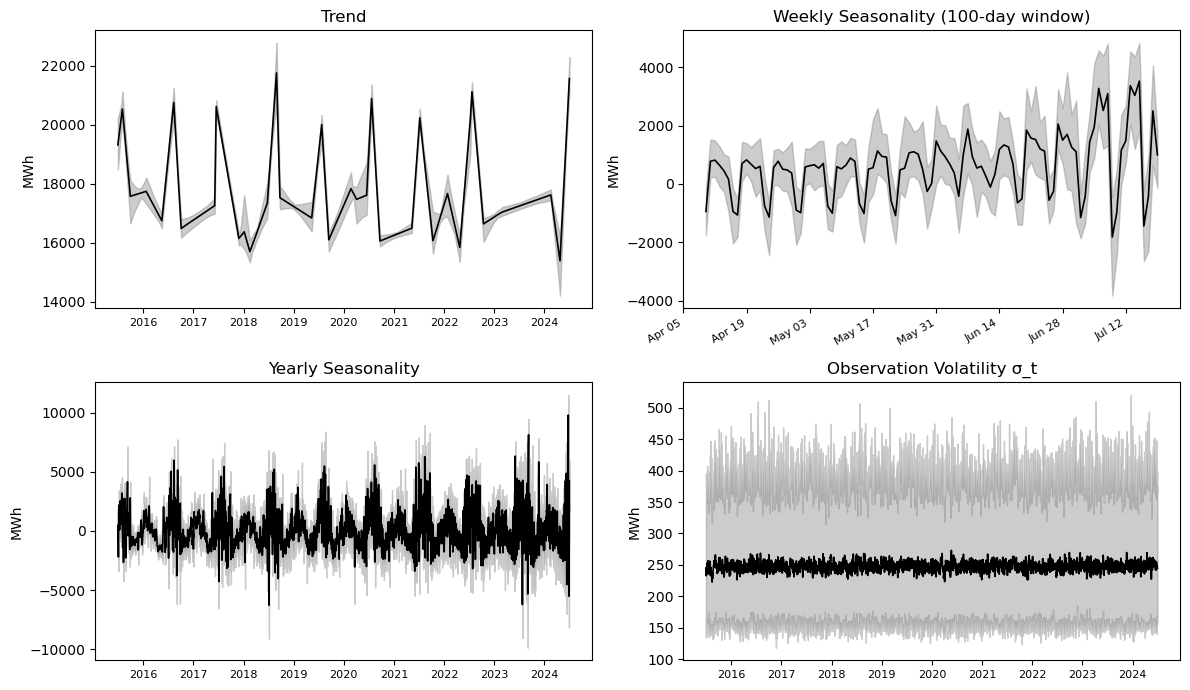

In [4]:
dates  = elec['date'].values
demand = elec['demand'].values

trend_mean = np.asarray(summary['Trend_sum']['Mean']).ravel()
trend_lo   = np.asarray(summary['Trend_sum']['CR_lower']).ravel()
trend_hi   = np.asarray(summary['Trend_sum']['CR_upper']).ravel()
s7_mean    = np.asarray(summary['Seasonal7_sum']['Mean']).ravel()
s7_lo      = np.asarray(summary['Seasonal7_sum']['CR_lower']).ravel()
s7_hi      = np.asarray(summary['Seasonal7_sum']['CR_upper']).ravel()
s365_mean  = np.asarray(summary['Seasonal365_sum']['Mean']).ravel()
s365_lo    = np.asarray(summary['Seasonal365_sum']['CR_lower']).ravel()
s365_hi    = np.asarray(summary['Seasonal365_sum']['CR_upper']).ravel()
volat_mean = np.asarray(summary['Volatility']['Mean']).ravel()
volat_lo   = np.asarray(summary['Volatility']['CR_lower']).ravel()
volat_hi   = np.asarray(summary['Volatility']['CR_upper']).ravel()

zoom    = slice(284, 385)   # ~100-day window
dates_z = dates[zoom]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

ax = axes[0, 0]
ax.fill_between(dates, trend_lo, trend_hi, color='grey', alpha=0.4)
ax.plot(dates, trend_mean, linewidth=1.2, color='black')
ax.set_title('Trend'); ax.set_ylabel('MWh')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[0, 1]
ax.fill_between(dates_z, s7_lo[zoom], s7_hi[zoom], color='grey', alpha=0.4)
ax.plot(dates_z, s7_mean[zoom], linewidth=1.2, color='black')
ax.set_title('Weekly Seasonality (100-day window)'); ax.set_ylabel('MWh')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax = axes[1, 0]
ax.fill_between(dates, s365_lo, s365_hi, color='grey', alpha=0.4)
ax.plot(dates, s365_mean, linewidth=1.2, color='black')
ax.set_title('Yearly Seasonality'); ax.set_ylabel('MWh')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1, 1]
ax.fill_between(dates, volat_lo, volat_hi, color='grey', alpha=0.4)
ax.plot(dates, volat_mean, linewidth=1.2, color='black')
ax.set_title('Observation Volatility σ_t'); ax.set_ylabel('MWh')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes.flatten():
    ax.tick_params(axis='x', labelsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'electricity_decomposition.pdf'), dpi=150,
            bbox_inches='tight')
plt.show()

## 4. Time-Varying Volatility in Detail

One of BASTION's distinguishing features — unavailable in any other decomposition method — is the explicit estimation of a time-varying observation standard deviation σ_t.  The plot below shows its posterior mean with 95% credible bands.

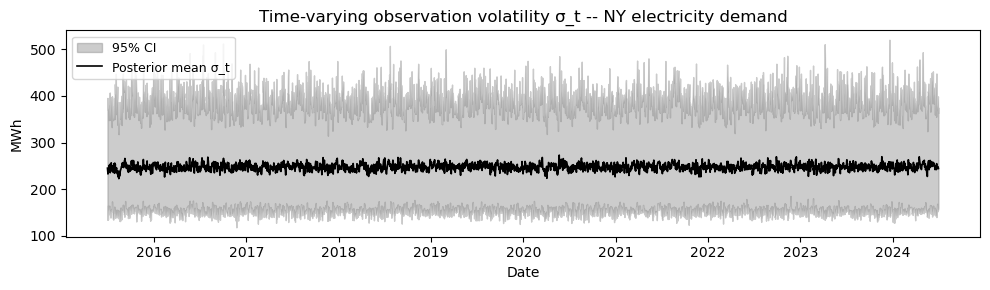

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(dates, volat_lo, volat_hi, color='grey', alpha=0.4, label='95% CI')
ax.plot(dates, volat_mean, linewidth=1.2, color='black', label='Posterior mean σ_t')
ax.set_xlabel('Date'); ax.set_ylabel('MWh')
ax.set_title('Time-varying observation volatility σ_t -- NY electricity demand')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'electricity_volatility.pdf'), dpi=150,
            bbox_inches='tight')
plt.show()

## 5. Metrics

### 5a. Simulation-average benchmarks (Cho & Matteson 2026, Tables 2 & 3)

The closest simulation scenario is **DGP 3** (quadratic trend, Fourier seasonality, stochastic volatility).  Not runnable via `pybastion`; shown as a reference.

| Method | Signal MSE | Trend MSE | Seasonal MSE |
|--------|------------|-----------|-------------|
| TBATS  | 11.307 | 10.509 | 0.900 |
| MSTL   | 3.041  | 0.364  | 2.683 |
| STR    | 0.706  | 0.274  | 0.444 |
| **BASTION** | **0.439** | **0.293** | **0.278** |

| Component | STR coverage | BASTION coverage |
|---|---|---|
| Signal | 0.940 | **0.995** |
| Trend | 0.812 | **0.929** |
| Seasonality | 0.847 | **0.981** |

*Source: Tables 2 & 3, DGP 3 in Cho & Matteson (2026).*

### 5b. In-sample fit statistics — this run

Since no ground truth is available for real data, the table below reports in-sample statistics computed from the current BASTION fit.  `Signal = Trend + Weekly + Yearly` (outlier component counted in remainder).

In [6]:
signal_elec = trend_mean + s7_mean + s365_mean
remainder_e = demand - signal_elec
R2 = float(1 - np.var(remainder_e) / np.var(demand))
rmse = float(np.sqrt(np.mean(remainder_e ** 2)))
trend_range = float(trend_mean.max() - trend_mean.min())
s7_range    = float(s7_mean.max() - s7_mean.min())
s365_range  = float(s365_mean.max() - s365_mean.min())
pct_var_trend  = float(np.var(trend_mean) / np.var(demand) * 100)
pct_var_s7     = float(np.var(s7_mean)    / np.var(demand) * 100)
pct_var_s365   = float(np.var(s365_mean)  / np.var(demand) * 100)
avg_volat      = float(np.mean(volat_mean))

fit_stats = pd.DataFrame(
    {
        'Statistic': [
            'Signal R² (in-sample)',
            'Remainder RMSE [MWh]',
            'Trend: peak-to-trough range [MWh]',
            'Weekly season: peak-to-trough range [MWh]',
            'Yearly season: peak-to-trough range [MWh]',
            'Trend: share of total variance',
            'Weekly season: share of variance',
            'Yearly season: share of variance',
            'Mean volatility σ_t [MWh]',
        ],
        'Value': [
            f'{R2:.1%}',
            f'{rmse:.1f}',
            f'{trend_range:.1f}',
            f'{s7_range:.1f}',
            f'{s365_range:.1f}',
            f'{pct_var_trend:.1f}%',
            f'{pct_var_s7:.1f}%',
            f'{pct_var_s365:.1f}%',
            f'{avg_volat:.1f}',
        ],
    }
).set_index('Statistic')
print('In-sample fit statistics -- this run')
print(fit_stats.to_string())
print()
print('R² = 1 - Var(remainder) / Var(demand); Signal = Trend + Weekly + Yearly.')

In-sample fit statistics -- this run
                                             Value
Statistic                                         
Signal R² (in-sample)                        98.7%
Remainder RMSE [MWh]                         288.2
Trend: peak-to-trough range [MWh]           6369.0
Weekly season: peak-to-trough range [MWh]  22505.9
Yearly season: peak-to-trough range [MWh]  16048.0
Trend: share of total variance               22.4%
Weekly season: share of variance             40.8%
Yearly season: share of variance             32.6%
Mean volatility σ_t [MWh]                    247.5

R² = 1 - Var(remainder) / Var(demand); Signal = Trend + Weekly + Yearly.
